<a href="https://colab.research.google.com/github/amurthy-sunysb/moment_4_mcsa/blob/stft_transform/STFT_2_ts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We take STFT and then convert to a time series.

We try it on the LIAS dataset and then generalize.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from sklearn.preprocessing import StandardScaler


In [2]:
data_path = "/content/drive/MyDrive/LIAS/mcsadc-motor-rotorbarfailure-1_2023"

In [3]:
lias_columns = ["timestamp", "isa", "isb", "isc", "vsa", "vsb", "vsc", "speed", "pos"]

T = 0.0007

In [4]:
healthy_low_indices = range(0, 18)
one_broken_low_indices = range(60, 68)
two_broken_low_indices = range(120, 128)

healthy_med_indices = range(20, 38)
one_broken_med_indices = range(80, 98)
two_broken_med_indices = range(140, 148)

healthy_high_indices = range(40, 58)
one_broken_high_indices = range(100, 118)
two_broken_high_indices = range(160, 178)

In [5]:
def get_data(data_path, indices):
  all_data = []

  for i in indices:
    filename = f"ccs{i}.csv"
    # get the data
    df = pd.read_csv(os.path.join(data_path, filename), header=None, names=lias_columns)
    df = df.set_index("timestamp")
    all_data.append(df)

  return all_data


In [6]:
all_H_L = get_data(data_path=data_path, indices=healthy_low_indices)
all_H_M = get_data(data_path=data_path, indices=healthy_med_indices)
all_H_H = get_data(data_path=data_path, indices=healthy_high_indices)

all_2B_L = get_data(data_path=data_path, indices=two_broken_low_indices)
all_2B_M = get_data(data_path=data_path, indices=two_broken_med_indices)
all_2B_H = get_data(data_path=data_path, indices=two_broken_high_indices)

In [11]:
len(all_H_L)

18

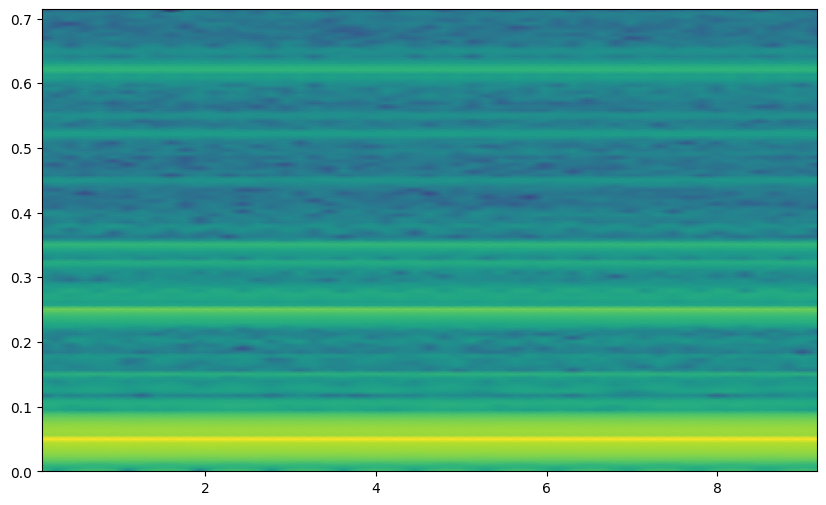

In [7]:
WINDOW_LENGTH = 256
freqs, times, Sx = signal.spectrogram(all_H_L[1]['isa'],
                                      fs=1/T,
                                      nperseg=WINDOW_LENGTH,
                                      noverlap=16)

fig, ax = plt.subplots(figsize=(10, 6))
ax.pcolormesh(times, freqs/1000, 10*np.log10(Sx), shading='gouraud')

In [8]:
Sx.shape

(129, 55)

In [9]:
power = np.abs(Sx) ** 2
log_power = np.log(power + 1e-8)

In [10]:
# Define band edges (Hz)
bands = [
    (0, 20),     # low
    (20, 50),    # low-mid
    (50, 100),   # mid
    (100, 200),  # high
    (200, 400)   # very high
]

In [12]:
band_series = []

for fmin, fmax in bands:
    idx = np.where((freqs >= fmin) & (freqs < fmax))[0]
    band_energy = log_power[idx, :].mean(axis=0)
    band_series.append(band_energy)

band_series = np.vstack(band_series).T  # shape: (time, bands)

In [13]:
band_series.shape

(55, 5)

<Axes: >

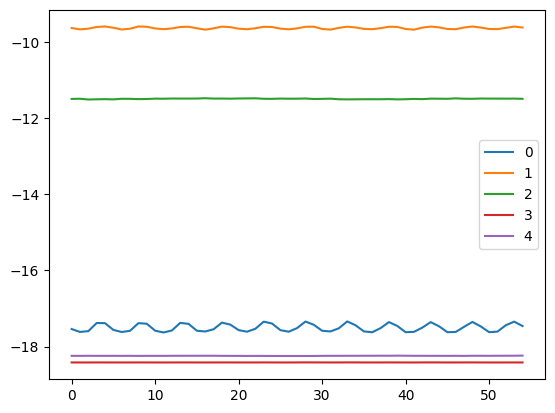

In [16]:
pd.DataFrame(band_series).plot()

# Doing it for 2B_L

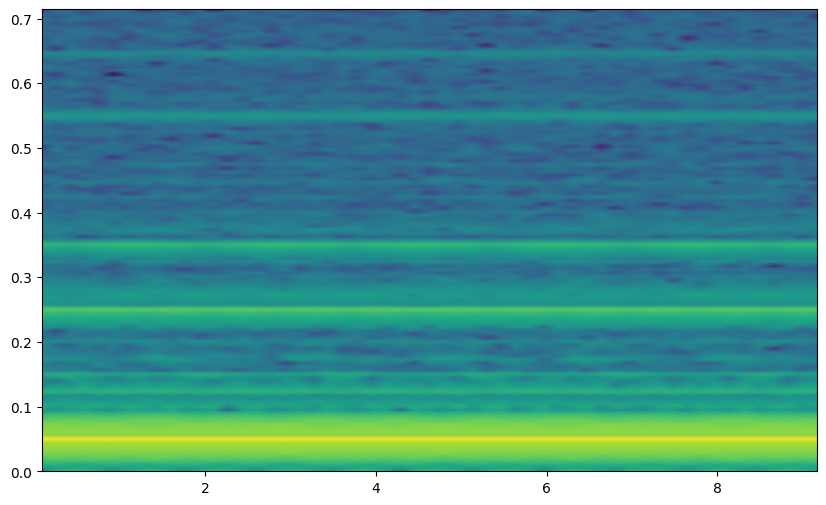

In [18]:
WINDOW_LENGTH = 256
freqs, times, Sx = signal.spectrogram(all_2B_H[1]['isa'],
                                      fs=1/T,
                                      nperseg=WINDOW_LENGTH,
                                      noverlap=16)

fig, ax = plt.subplots(figsize=(10, 6))
ax.pcolormesh(times, freqs/1000, 10*np.log10(Sx), shading='gouraud')

In [59]:
Sx.shape

(129, 55)

In [60]:
power = np.abs(Sx) ** 2
log_power = np.log(power + 1e-8)

In [61]:
band_series = []

for fmin, fmax in bands:
    idx = np.where((freqs >= fmin) & (freqs < fmax))[0]
    band_energy = log_power[idx, :].mean(axis=0)
    band_series.append(band_energy)

band_series = np.vstack(band_series).T  # shape: (time, bands)

<Axes: >

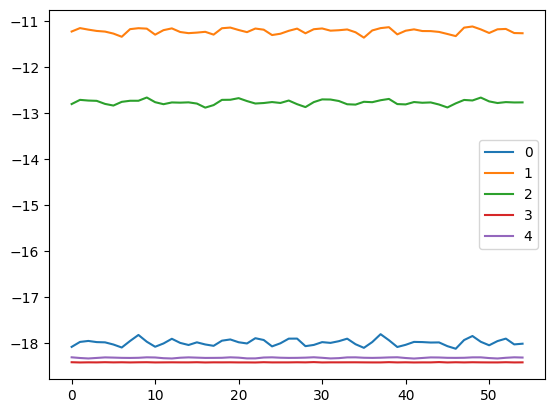

In [62]:
pd.DataFrame(band_series).plot()

Generalizing into a function

In [18]:
def transform_via_stft(data: pd.Series,
                       time_period: float,
                       window_length: int,
                       noverlap: int,
                       window: str,
                       frequency_bands: list[tuple[int, int]]) -> pd.DataFrame:

  # Get STFT of the data
  freqs, times, Sx = signal.spectrogram(data,
                                        fs=1/time_period,
                                        nperseg=window_length,
                                        noverlap=noverlap,
                                        window=window)


  # Convert to power and then take log
  power = np.abs(Sx) ** 2

  log_power = np.log(power + 1e-8) # Small perturbation in case of 0 power

  band_series = []

  # Aggregate the energy across bands using mean
  for fmin, fmax in frequency_bands:
      idx = np.where((freqs >= fmin) & (freqs < fmax))[0]
      band_energy = log_power[idx, :].mean(axis=0)
      band_series.append(band_energy)

  band_series = np.vstack(band_series).T  # shape: (time, bands)

  # Normalize per band
  scaler = StandardScaler()
  band_series_norm = scaler.fit_transform(band_series)

  # Convert to dataframe and add the times
  df = pd.DataFrame(band_series_norm)
  df['time'] = times
  df=df.set_index("time")

  return df


In [22]:
len(times)

55

In [21]:
Sx.shape

(129, 55)

In [19]:
df_2B_H = transform_via_stft(data=all_2B_H[1]['isa'],
                        time_period=0.0007,
                        window_length=256,
                        noverlap=16,
                        window="hann",
                        frequency_bands=bands)

In [21]:
df_2B_H

,0,1,2,3,4
time,,,,,
0.0896,-0.826786,0.107525,1.267279,-0.550307,1.283525
0.2576,-0.479556,-0.541950,0.003275,-1.089628,-0.576748
0.4256,0.656701,-0.744707,-0.904901,-0.294510,-1.845095
0.5936,0.121699,-0.807000,-1.081063,-0.533686,-0.361144
0.7616,-0.653685,-0.895309,-1.127798,0.290222,1.000826
0.9296,-0.849691,-0.945813,-0.879379,1.766014,0.455162
1.0976,-0.714465,-0.126087,-0.063196,-0.404298,-0.446086
1.2656,-0.001905,1.273006,0.815841,-0.204918,-0.625474
1.4336,2.300264,2.032589,1.193971,1.522842,-0.052615


array([<Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>], dtype=object)

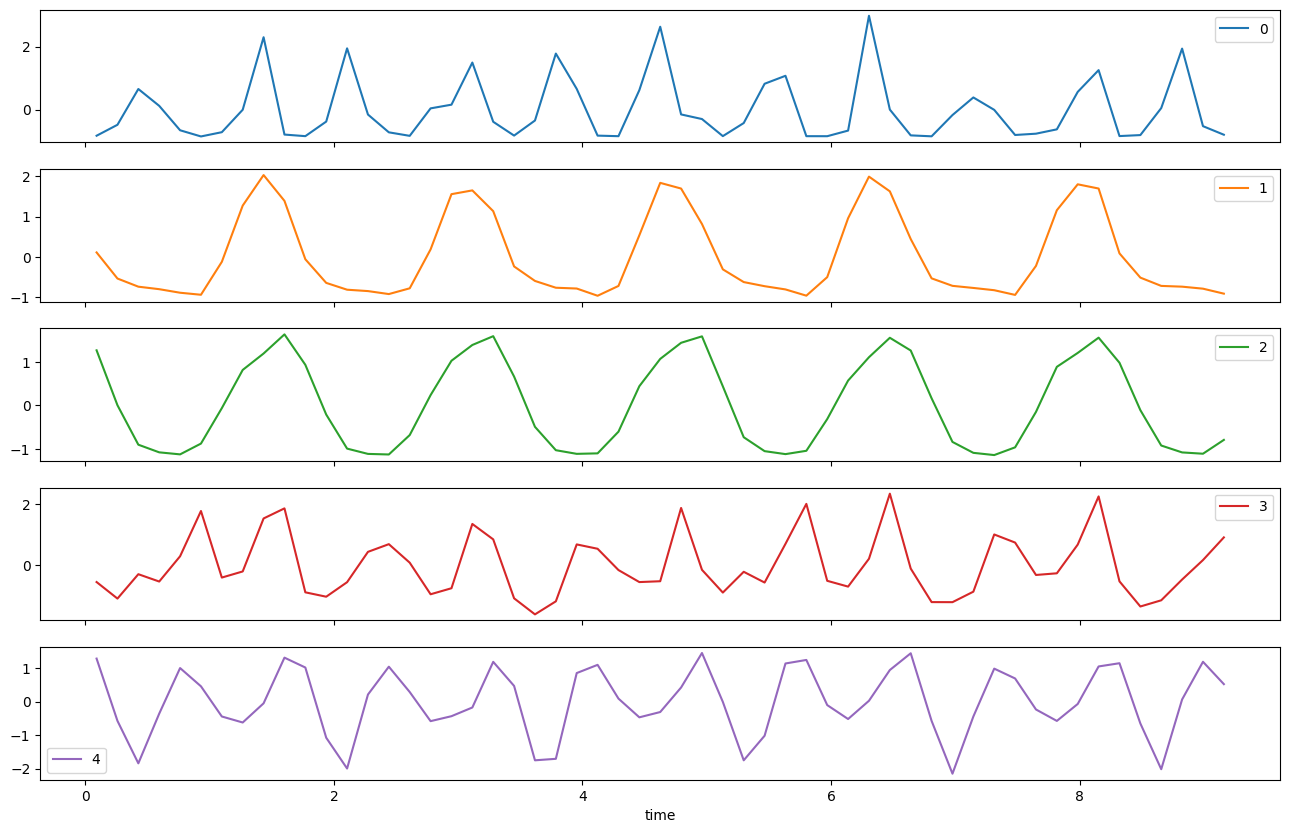

In [20]:
df_2B_H.plot(subplots=True, figsize=(16, 10))

In [22]:
df_H_L = transform_via_stft(data=all_H_L[1]['isa'],
                        time_period=0.0007,
                        window_length=256,
                        noverlap=16,
                        window="hann",
                        frequency_bands=bands)

array([<Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>], dtype=object)

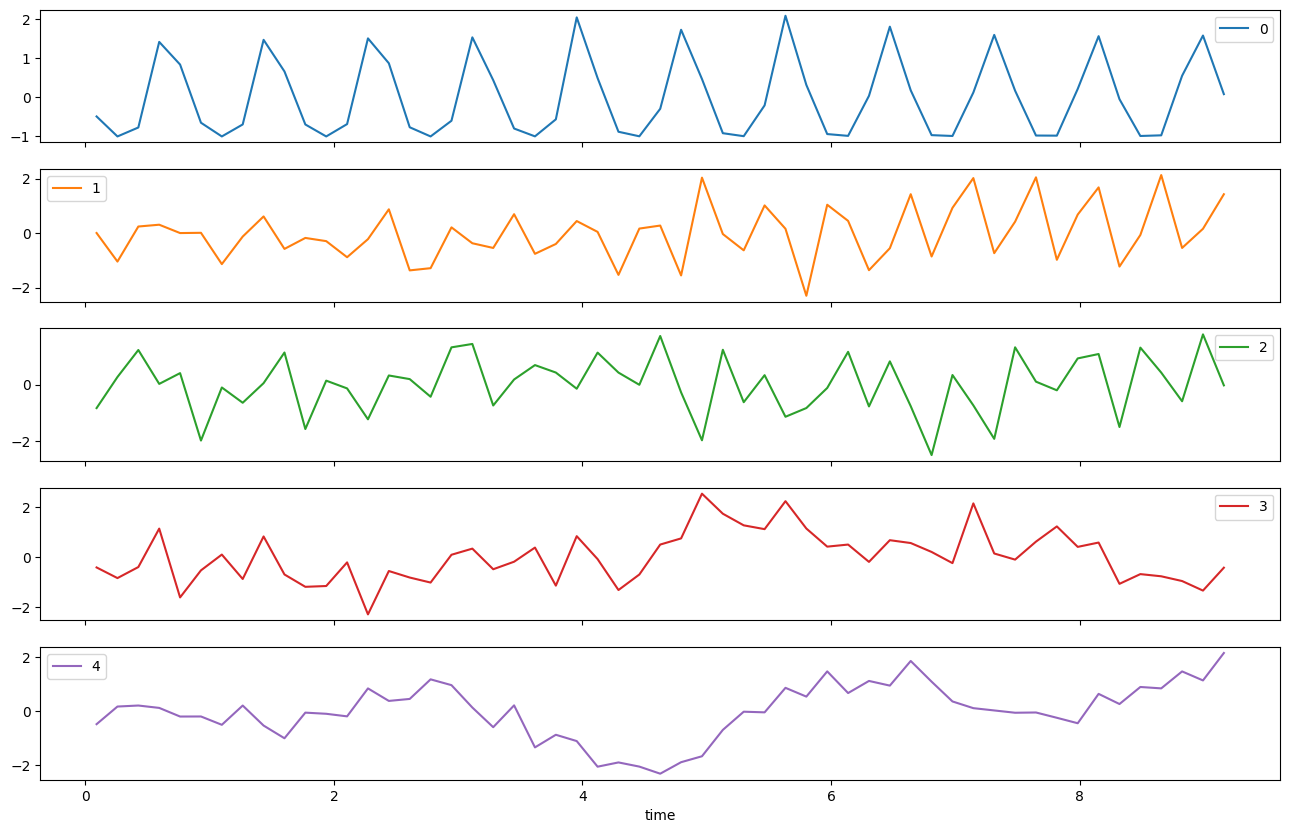

In [23]:
df_H_L.plot(subplots=True, figsize=(16, 10))

In [24]:
df_ieee_healthy = pd.read_csv("/content/drive/MyDrive/healthy_motor_50percent.csv", index_col="timestamp")
df_ieee_4b = pd.read_csv("/content/drive/MyDrive/faulty_4bars_50percent.csv", index_col="timestamp")

In [63]:
df_ieee_4b['Ia']

,Ia
timestamp,
0.000000,0.004167
0.000018,0.008333
0.000036,0.008333
0.000054,-0.008333
0.000072,0.000000
...,...
17.999928,-0.162500
17.999946,-0.158333
17.999964,-0.158333


In [25]:
df_stft_ieee_h = transform_via_stft(data=df_ieee_healthy[3:]['Ia'],
                        time_period=0.000018,
                        window_length=1024,
                        noverlap=128,
                        window="hann",
                        frequency_bands=bands)

/tmp/ipython-input-1454611504.py:1: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  df_stft_ieee_h = transform_via_stft(data=df_ieee_healthy[3:]['Ia'],
/tmp/ipython-input-987421110.py:26: RuntimeWarning: Mean of empty slice.
  band_energy = log_power[idx, :].mean(axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeW

array([<Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>], dtype=object)

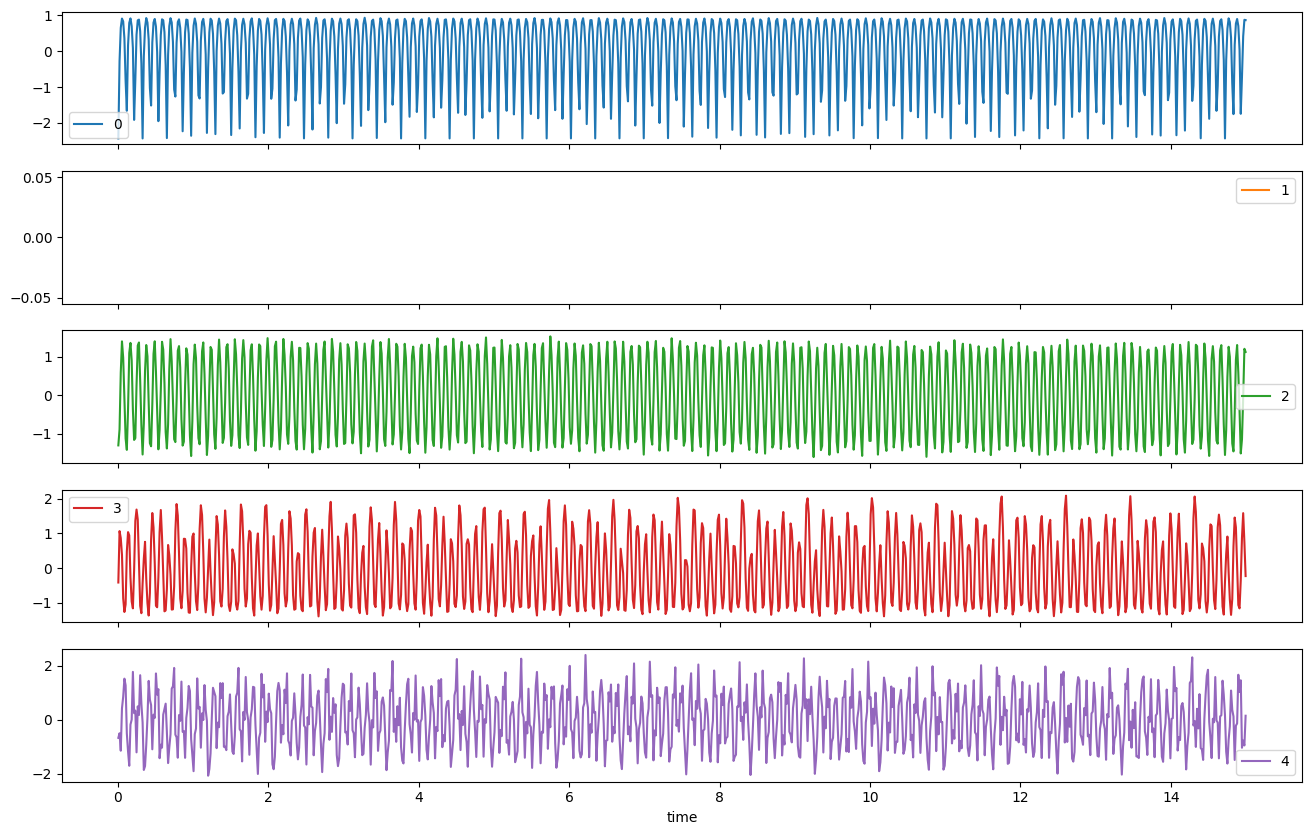

In [26]:
df_stft_ieee_h.plot(subplots=True, figsize=(16, 10))

In [27]:
df_stft_ieee_4b = transform_via_stft(data=df_ieee_4b[3:]['Ia'],
                        time_period=0.000018,
                        window_length=1024,
                        noverlap=128,
                        window="hann",
                        frequency_bands=bands)

/tmp/ipython-input-391947162.py:1: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  df_stft_ieee_4b = transform_via_stft(data=df_ieee_4b[3:]['Ia'],
/tmp/ipython-input-987421110.py:26: RuntimeWarning: Mean of empty slice.
  band_energy = log_power[idx, :].mean(axis=0)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarnin

array([<Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>], dtype=object)

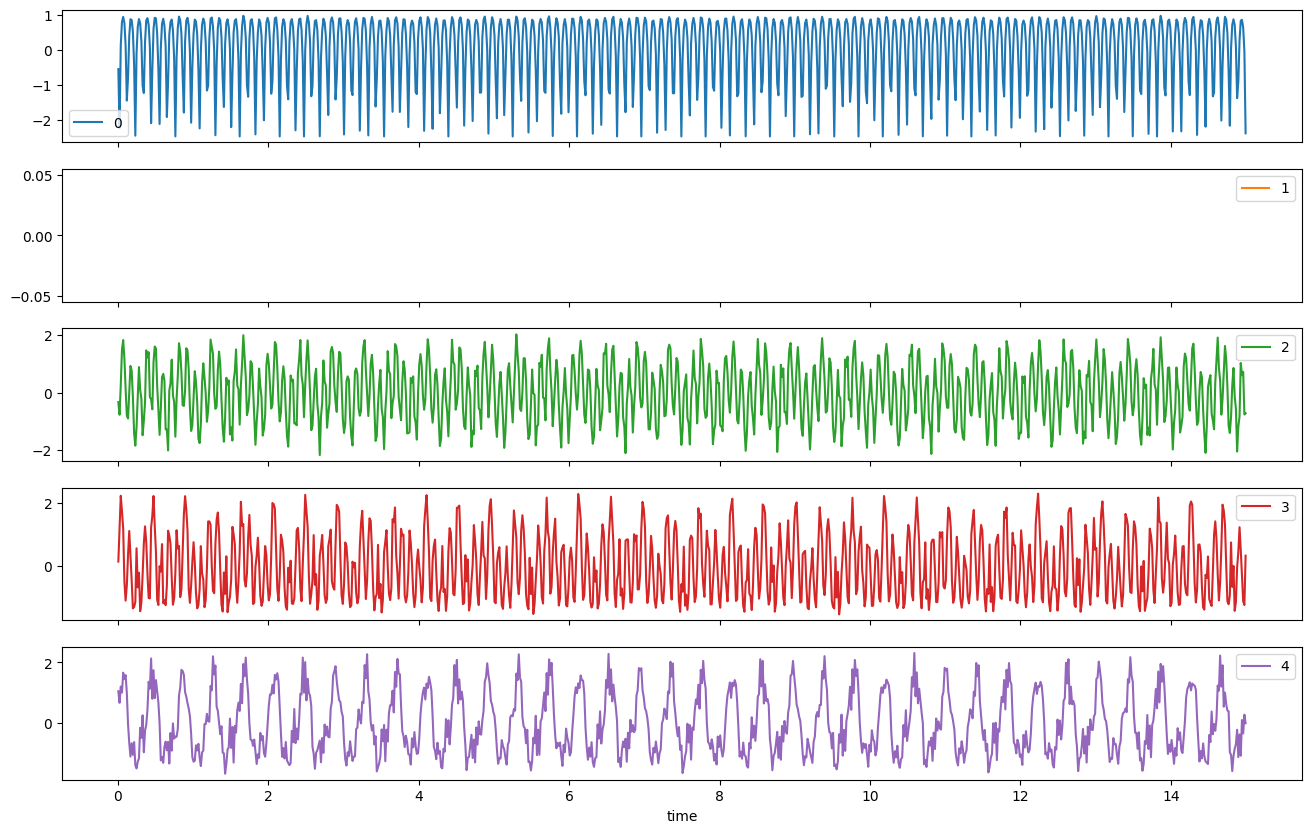

In [28]:
df_stft_ieee_4b.plot(subplots=True, figsize=(16, 10))